# LHD CMOS Echelle — Order Table

This notebook introduces the LHD CMOS echelle spectrometer defaults and inspects
the predicted per-order dispersion and wavelength coverage.

**Instrument**: Newport echelle 46.1 gr/mm, blaze 32°, f = 304.8 mm,
Andor Zyla 4.2 sCMOS (2560 × 2160 px, 6.5 µm pixel).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from echelle_optics import lhd_cmos_echelle

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_rows", 40)

In [2]:
spec = lhd_cmos_echelle()
df = spec.order_table(30, 58)
df

,order,center_wavelength_nm,free_spectral_range_nm,dispersion_nm_per_px,detector_span_nm,wavelength_min_nm,wavelength_max_nm
0,30,766.3330,25.5444,0.0131,33.4762,749.5949,783.0711
1,31,741.6126,23.9230,0.0127,32.3964,725.4144,757.8108
2,32,718.4372,22.4512,0.0123,31.3840,702.7452,734.1292
3,33,696.6664,21.1111,0.0119,30.4329,681.4499,711.8828
4,34,676.1762,19.8875,0.0115,29.5379,661.4072,690.9451
5,35,656.8569,18.7673,0.0112,28.6939,642.5099,671.2038
6,36,638.6108,17.7392,0.0109,27.8969,624.6624,652.5593
7,37,621.3511,16.7933,0.0106,27.1429,607.7796,634.9225
8,38,604.9997,15.9210,0.0103,26.4286,591.7854,618.2140
9,39,589.4869,15.1150,0.0101,25.7510,576.6114,602.3624


## Plots

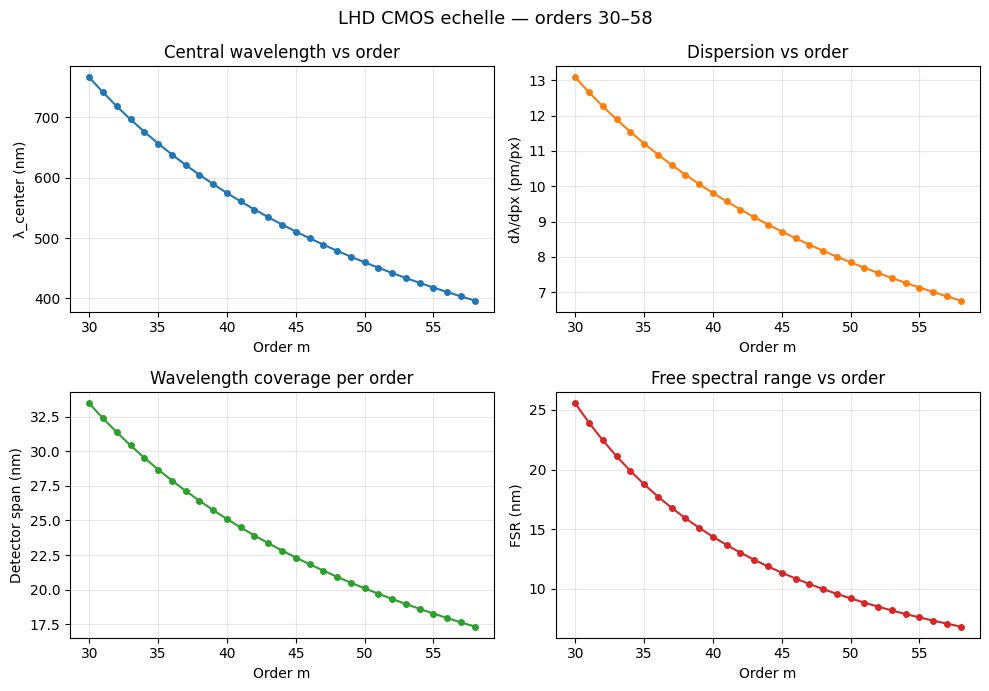

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
m = df["order"]

ax = axes[0, 0]
ax.plot(m, df["center_wavelength_nm"], "o-", ms=4)
ax.set_xlabel("Order m")
ax.set_ylabel("λ_center (nm)")
ax.set_title("Central wavelength vs order")
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(m, df["dispersion_nm_per_px"] * 1000, "o-", ms=4, color="tab:orange")
ax.set_xlabel("Order m")
ax.set_ylabel("dλ/dpx (pm/px)")
ax.set_title("Dispersion vs order")
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(m, df["detector_span_nm"], "o-", ms=4, color="tab:green")
ax.set_xlabel("Order m")
ax.set_ylabel("Detector span (nm)")
ax.set_title("Wavelength coverage per order")
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(m, df["free_spectral_range_nm"], "o-", ms=4, color="tab:red")
ax.set_xlabel("Order m")
ax.set_ylabel("FSR (nm)")
ax.set_title("Free spectral range vs order")
ax.grid(True, alpha=0.3)

fig.suptitle("LHD CMOS echelle — orders 30–58", fontsize=13)
plt.tight_layout()
plt.show()

## Physics background

### Physical order *m*

The reflective grating equation is

$$m \lambda = d (\sin\alpha + \sin\beta)$$

where $d$ is the groove spacing, $\alpha$ is the incidence angle, and $\beta$ is
the diffraction angle.  In quasi-Littrow geometry $\alpha \approx \beta \approx \theta_B$
(blaze angle), so

$$K \equiv 2 d \sin\theta_B \quad \Rightarrow \quad \lambda_{\text{center}} = K / m$$

For the LHD grating: $d = 1 / 46.1 \approx 21.69\,\mu\text{m}$,
$\theta_B = 32°$, giving

$$K = 2 \times 21690\,\text{nm} \times \sin 32° \approx 23\,002\,\text{nm}$$

Hence $\lambda_{\text{center}} \approx 23\,000 / m$ nm.

### Why $\text{d}\lambda/\text{dpx} \approx 0.392 / m$

Differentiating the grating equation with respect to position on the detector:

$$\frac{d\lambda}{dx} = \frac{d \cos\beta}{m f}$$

Converting to per-pixel (pixel size $p = 6.5\,\mu\text{m}$, $f = 304.8\,\text{mm}$):

$$\frac{d\lambda}{\text{dpx}} = \frac{d \cos\theta_B \cdot p}{m f}
  \approx \frac{21.69\,\mu\text{m} \times 0.848 \times 6.5\,\mu\text{m}}{m \times 304\,800\,\mu\text{m}}
  \approx \frac{0.392}{m}\,\text{nm/px}$$

### Why red orders cover wider spans

The detector span is simply $N_{\text{px}} \times d\lambda/\text{dpx}$.
Since $d\lambda/\text{dpx} \propto 1/m$ and low orders correspond to longer
(redder) wavelengths, red orders have both larger dispersion and wider total
wavelength coverage on the detector.